In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv("P2Deliverable2_raw.csv")
df.sample(5)

,X,Y,OBJECTID,NCESSCH,SURVYEAR,STABR,LEAID,ST_LEAID,LEA_NAME,SCH_NAME,...,TRALM,TRALF,TR,WHALM,WHALF,WH,LATCOD,LONCOD,TOTAL_RACE_CONS,TOTAL_GRADE_CONS
65830,-81.610517,41.417375,67600,390147305721,2022-2023,OH,3901473,OH-013170,The Brilliance School,The Brilliance School,...,12.0,5.0,17.0,4.0,2.0,6.0,41.417375,-81.610517,True,True
69850,-95.991917,35.962013,71633,401272002896,2022-2023,OK,4012720,OK-72-I013,GLENPOOL,GLENPOOL LOWER ES,...,26.0,45.0,71.0,74.0,64.0,138.0,35.962013,-95.991917,True,True
40217,-71.194832,42.690888,41756,250547002267,2022-2023,MA,2505470,MA-0823,Greater Lawrence Regional Vocational Technical,Gr Lawrence Regional Vocational Technical,...,3.0,5.0,8.0,173.0,93.0,266.0,42.690888,-71.194832,False,True
40661,-71.335155,42.120368,42201,250864000317,2022-2023,MA,2508640,MA-0208,Norfolk,H Olive Day,...,11.0,8.0,19.0,222.0,213.0,435.0,42.120368,-71.335155,True,True
74153,-75.183400,39.985300,75954,421899003662,2022-2023,PA,4218990,PA-126515001,Philadelphia City SD,Blaine James G Sch,...,4.0,1.0,5.0,2.0,2.0,4.0,39.985300,-75.183400,True,True


--- Statistics for LSTATE ---
Label Mapping: {'AK': np.int64(0), 'AL': np.int64(1), 'AR': np.int64(2), 'AZ': np.int64(3), 'CA': np.int64(4), 'CO': np.int64(5), 'CT': np.int64(6), 'DC': np.int64(7), 'DE': np.int64(8), 'FL': np.int64(9), 'GA': np.int64(10), 'HI': np.int64(11), 'IA': np.int64(12), 'ID': np.int64(13), 'IL': np.int64(14), 'IN': np.int64(15), 'KS': np.int64(16), 'KY': np.int64(17), 'LA': np.int64(18), 'MA': np.int64(19), 'MD': np.int64(20), 'ME': np.int64(21), 'MI': np.int64(22), 'MN': np.int64(23), 'MO': np.int64(24), 'MP': np.int64(25), 'MS': np.int64(26), 'MT': np.int64(27), 'NC': np.int64(28), 'ND': np.int64(29), 'NE': np.int64(30), 'NH': np.int64(31), 'NJ': np.int64(32), 'NM': np.int64(33), 'NV': np.int64(34), 'NY': np.int64(35), 'OH': np.int64(36), 'OK': np.int64(37), 'OR': np.int64(38), 'PA': np.int64(39), 'PR': np.int64(40), 'RI': np.int64(41), 'SC': np.int64(42), 'SD': np.int64(43), 'TN': np.int64(44), 'TX': np.int64(45), 'UT': np.int64(46), 'VA': np.int64(47), 'VI'

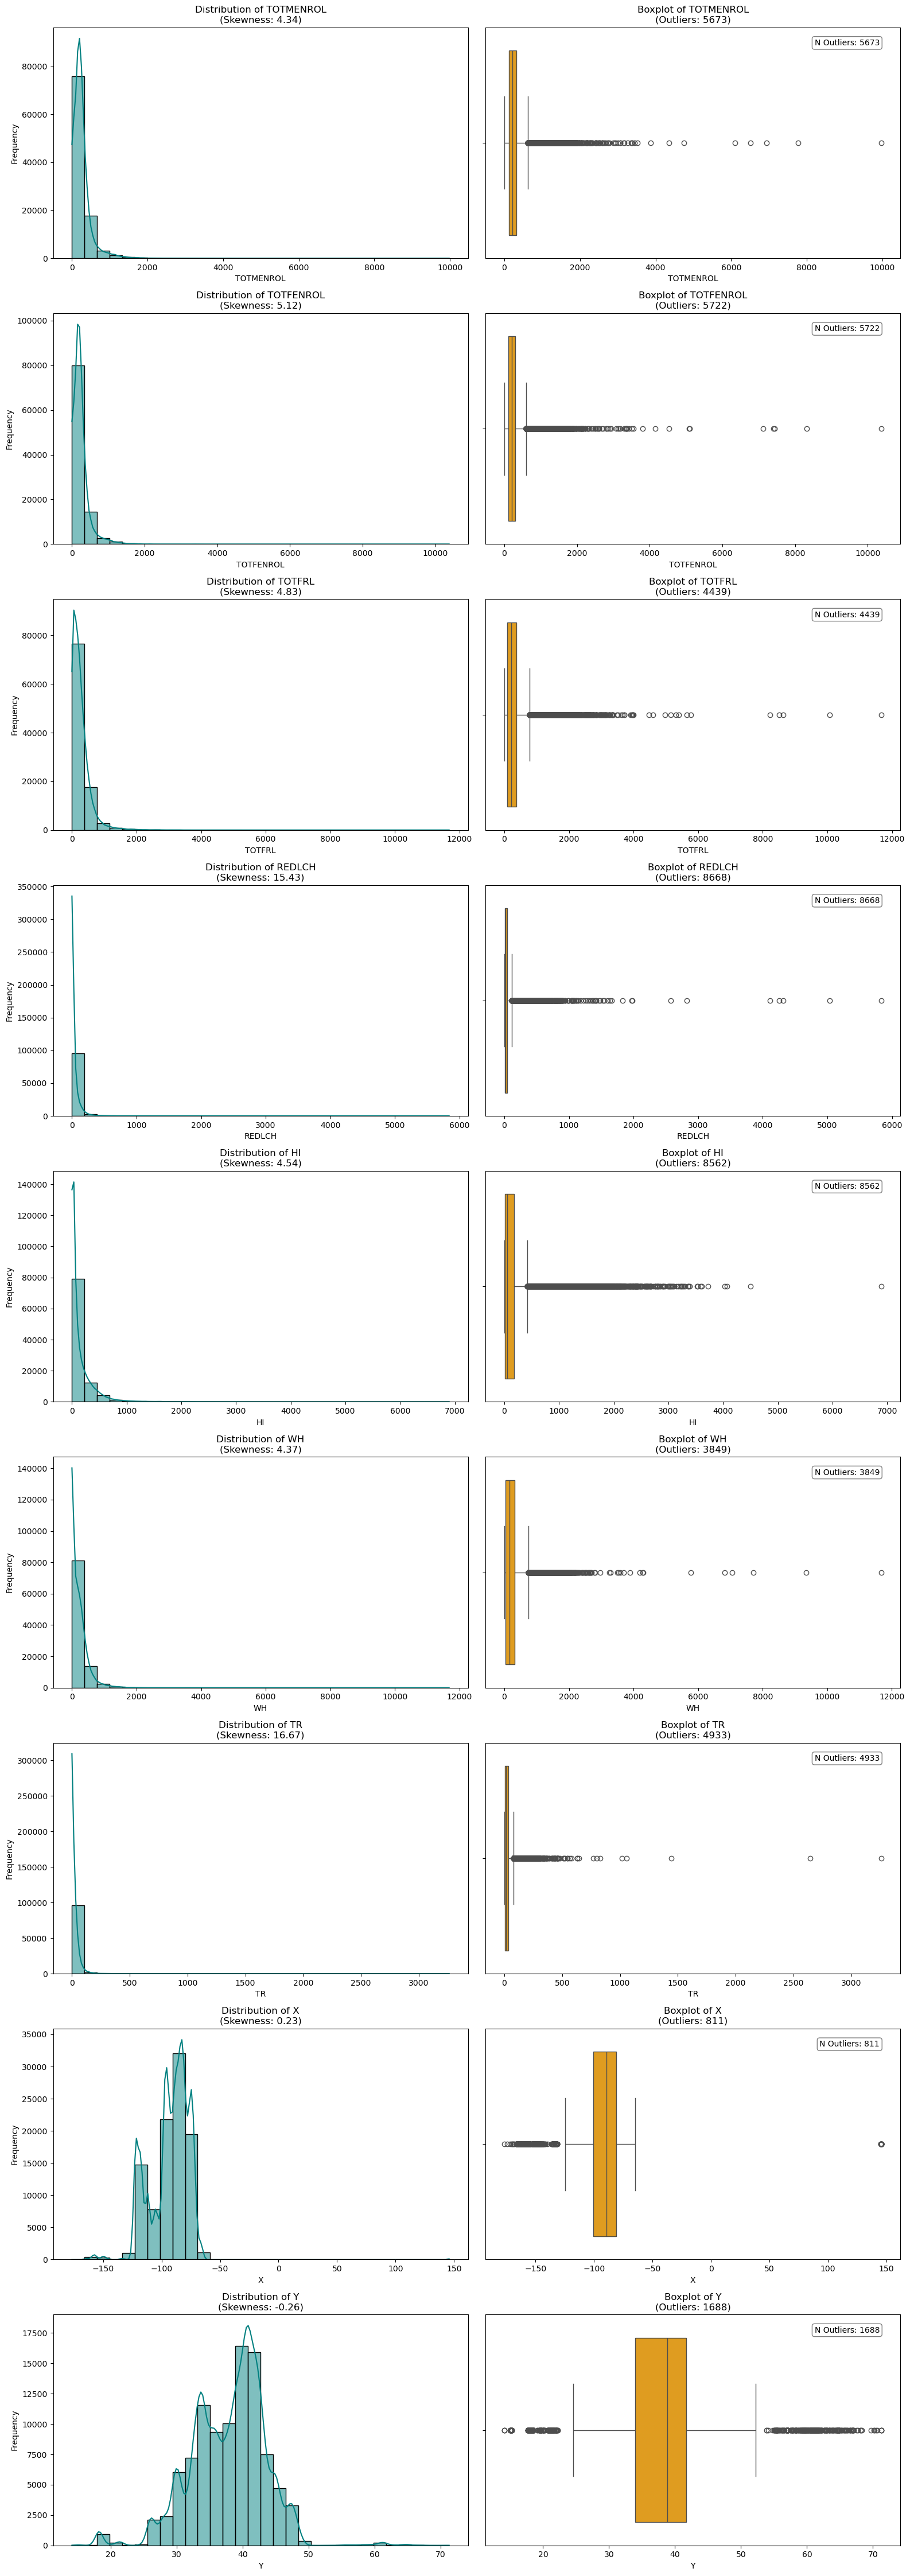

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder

cols = ['LSTATE', 'X', 'Y', 'TOTMENROL', 'TOTFENROL', 'TOTFRL', 'HI', 'SCHOOL_TYPE_TEXT', 'WH', 'REDLCH', 'TR', 'SCHOOL_LEVEL', 'GSHI']
cat_cols = ['LSTATE', 'SCHOOL_TYPE_TEXT', 'SCHOOL_LEVEL', 'GSHI']
num_cols = ['TOTMENROL', 'TOTFENROL', 'TOTFRL','REDLCH','HI', 'WH', 'TR', 'X', 'Y']
le = LabelEncoder()

X = df[cols]

Y = df['STUTERATIO']
# --- Categorical Columns: Mappings and Raw Counts (Least to Most) ---
for col in cat_cols:
    # Fitting the encoder to show the user what the numbers represent
    X[col] = le.fit_transform(X[col].astype(str))
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    
    print(f"--- Statistics for {col} ---")
    print(f"Label Mapping: {mapping}")
    
    # .value_counts(ascending=True) sorts by frequency (rarest first)
    # We remove normalize=True to get actual numbers
    print("Actual Counts (Least to Most):")
    print(df[col].value_counts(ascending=True))
    print("-" * 40)

# --- Numerical Distribution & Boxplots with Outlier Counts ---
# Creating 2 columns: Histograms on left, Boxplots on right
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(16, 5 * len(num_cols)))

for i, col in enumerate(num_cols):
    # 1. Calculate Outliers using IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count rows outside the bounds
    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    skew_val = df[col].skew()
    
    # 2. Plot Histogram (KDE)
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='teal', bins=30)
    axes[i, 0].set_title(f'Distribution of {col}\n(Skewness: {skew_val:.2f})')
    axes[i, 0].set_ylabel('Frequency')

    # 3. Plot Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='orange')
    axes[i, 1].set_title(f'Boxplot of {col}\n(Outliers: {outliers_count})')
    
    # Optional: Annotate the outlier count directly on the plot
    axes[i, 1].text(0.95, 0.95, f'N Outliers: {outliers_count}', 
                    transform=axes[i, 1].transAxes, 
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

## Task 1. Data Balancing
Choose between the Original Data or Transformed Data.  
N.B. Test only on the original test set, not on the balanced/transformed dataset.

### b. Handling Outliers & Unequal Variance for Regression:

##### Normalization

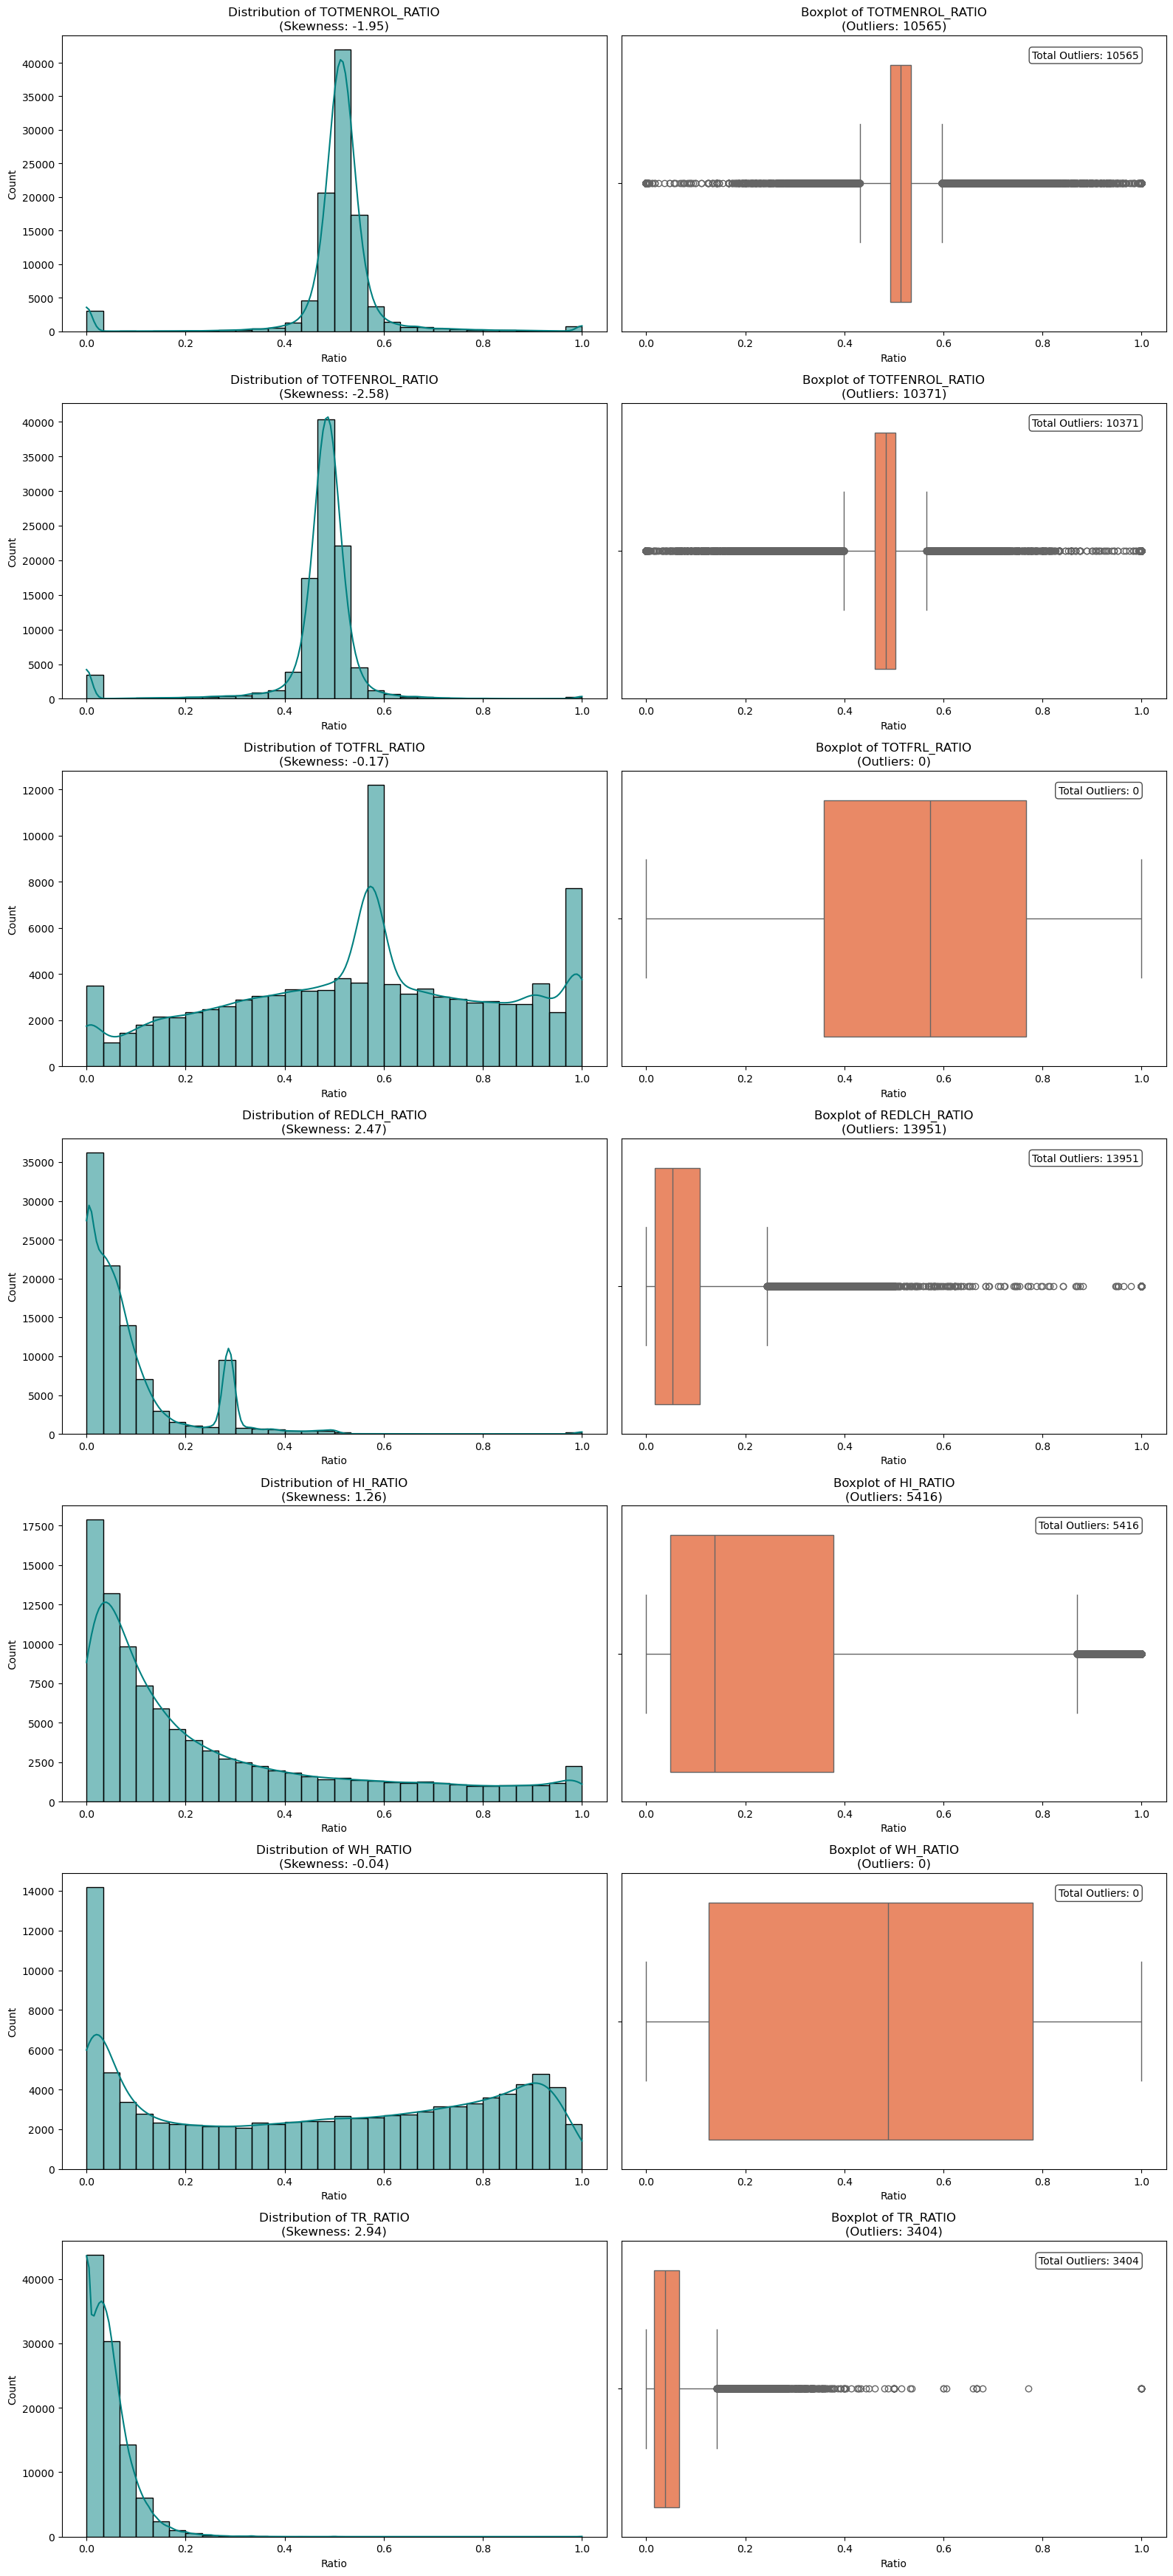

,LSTATE,X,Y,TOTMENROL,TOTFENROL,TOTFRL,HI,SCHOOL_TYPE_TEXT,WH,REDLCH,TR,SCHOOL_LEVEL,GSHI,TOTMENROL_RATIO,TOTFENROL_RATIO,TOTFRL_RATIO,REDLCH_RATIO,HI_RATIO,WH_RATIO,TR_RATIO
32699,12,-93.102017,41.329034,167.0,174.0,189.0,13.0,2,305.0,18.0,18.0,0,4,0.489736,0.510264,0.554252,0.052786,0.038123,0.894428,0.052786
92665,50,-122.313634,47.388328,254.0,265.0,312.0,148.0,2,126.0,45.0,74.0,0,4,0.488462,0.509615,0.600000,0.086538,0.284615,0.242308,0.142308
83841,45,-97.390519,32.730020,1.0,2.0,2.0,1.0,0,2.0,1.0,0.0,5,10,0.333333,0.666667,0.666667,0.333333,0.333333,0.666667,0.000000
71262,38,-122.875600,44.848700,308.0,292.0,400.0,141.0,2,420.0,0.0,27.0,0,4,0.513333,0.486667,0.666667,0.000000,0.235000,0.700000,0.045000
94702,52,-82.130113,38.863713,180.0,171.0,201.0,1.0,2,328.0,101.0,11.0,0,1,0.512821,0.487179,0.572650,0.287749,0.002849,0.934473,0.031339


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

count_cols = ['TOTMENROL', 'TOTFENROL', 'TOTFRL', 'REDLCH', 'HI', 'WH', 'TR']

# 1. Create ratio columns
for col in count_cols:
    # Use .div() to handle division and avoid errors if TOTAL is 0
    X[f'{col}_RATIO'] = X[col] / df['TOTAL']

# Fill any resulting NaNs with 0
ratio_cols = [f'{c}_RATIO' for c in count_cols]
X[ratio_cols] = X[ratio_cols].fillna(0)

# 2. Setup the plotting grid: 7 rows (for each column), 2 columns (Hist vs Box)
fig, axes = plt.subplots(nrows=len(count_cols), ncols=2, figsize=(16, 5 * len(count_cols)))

for i, col in enumerate(count_cols):
    ratio_col = f'{col}_RATIO'
    data = X[ratio_col]
    
    # --- Calculate Outliers using IQR Method ---
    # $Q1$ is the 25th percentile, $Q3$ is the 75th percentile
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count data points outside the bounds
    outliers_count = ((data < lower_bound) | (data > upper_bound)).sum()
    skew_val = data.skew()

    # --- Plot 1: Histogram (KDE) ---
    sns.histplot(data, kde=True, ax=axes[i, 0], color='teal', bins=30)
    axes[i, 0].set_title(f'Distribution of {ratio_col}\n(Skewness: {skew_val:.2f})', fontsize=12)
    axes[i, 0].set_xlabel('Ratio')

    # --- Plot 2: Boxplot ---
    sns.boxplot(x=data, ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'Boxplot of {ratio_col}\n(Outliers: {outliers_count})', fontsize=12)
    axes[i, 1].set_xlabel('Ratio')
    
    # Add an annotation box inside the plot for the outlier count
    axes[i, 1].text(0.95, 0.95, f'Total Outliers: {outliers_count}', 
                    transform=axes[i, 1].transAxes, 
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Adjust layout to prevent overlapping titles/axes
plt.tight_layout()
plt.show()

# Show sample of updated DataFrame
X.sample(5)

##### Log Tranformation

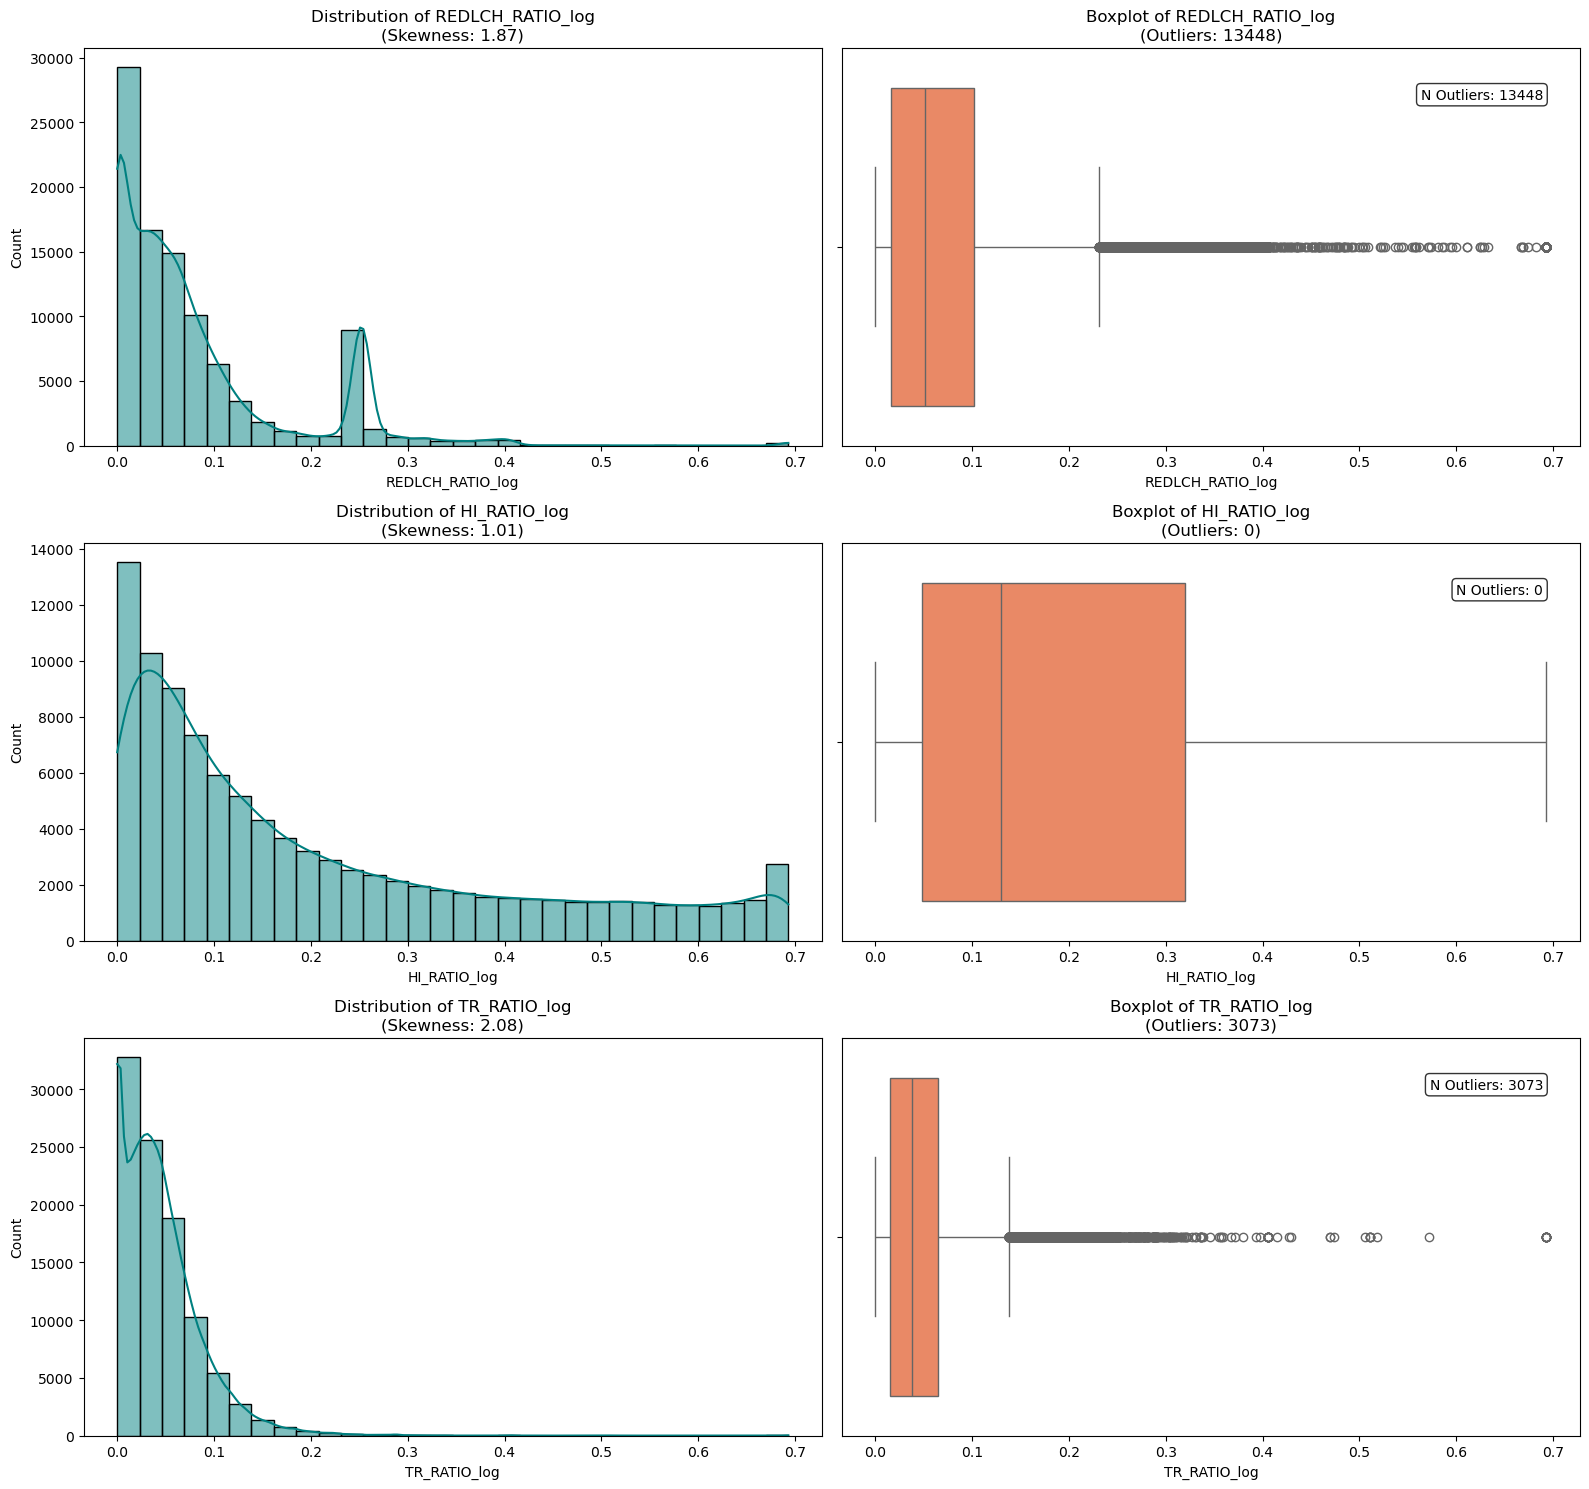

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

log_cols_base = ['REDLCH_RATIO', 'HI_RATIO', 'TR_RATIO']
log_cols_final = [f'{col}_log' for col in log_cols_base]

# 1. Apply transformations (keeping it here for completeness)
for col in log_cols_base:
    X[f'{col}_log'] = np.log1p(X[col])

# 2. Setup Plotting: 3 rows (one per variable), 2 columns (Dist vs Box)
fig, axes = plt.subplots(nrows=len(log_cols_final), ncols=2, figsize=(16, 5 * len(log_cols_final)))

for i, col in enumerate(log_cols_final):
    data = X[col]
    
    # --- Calculate Outliers (IQR Method) ---
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ((data < lower_bound) | (data > upper_bound)).sum()
    
    skew_val = data.skew()

    # --- Plot 1: Histogram ---
    sns.histplot(data, kde=True, ax=axes[i, 0], color='teal', bins=30)
    axes[i, 0].set_title(f'Distribution of {col}\n(Skewness: {skew_val:.2f})', fontsize=12)

    # --- Plot 2: Boxplot ---
    sns.boxplot(x=data, ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'Boxplot of {col}\n(Outliers: {outliers_count})', fontsize=12)
    
    # Add a visual label for the outlier count
    axes[i, 1].text(0.95, 0.9, f'N Outliers: {outliers_count}', 
                    transform=axes[i, 1].transAxes, 
                    ha='right', va='top', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

##### Robust Scaler

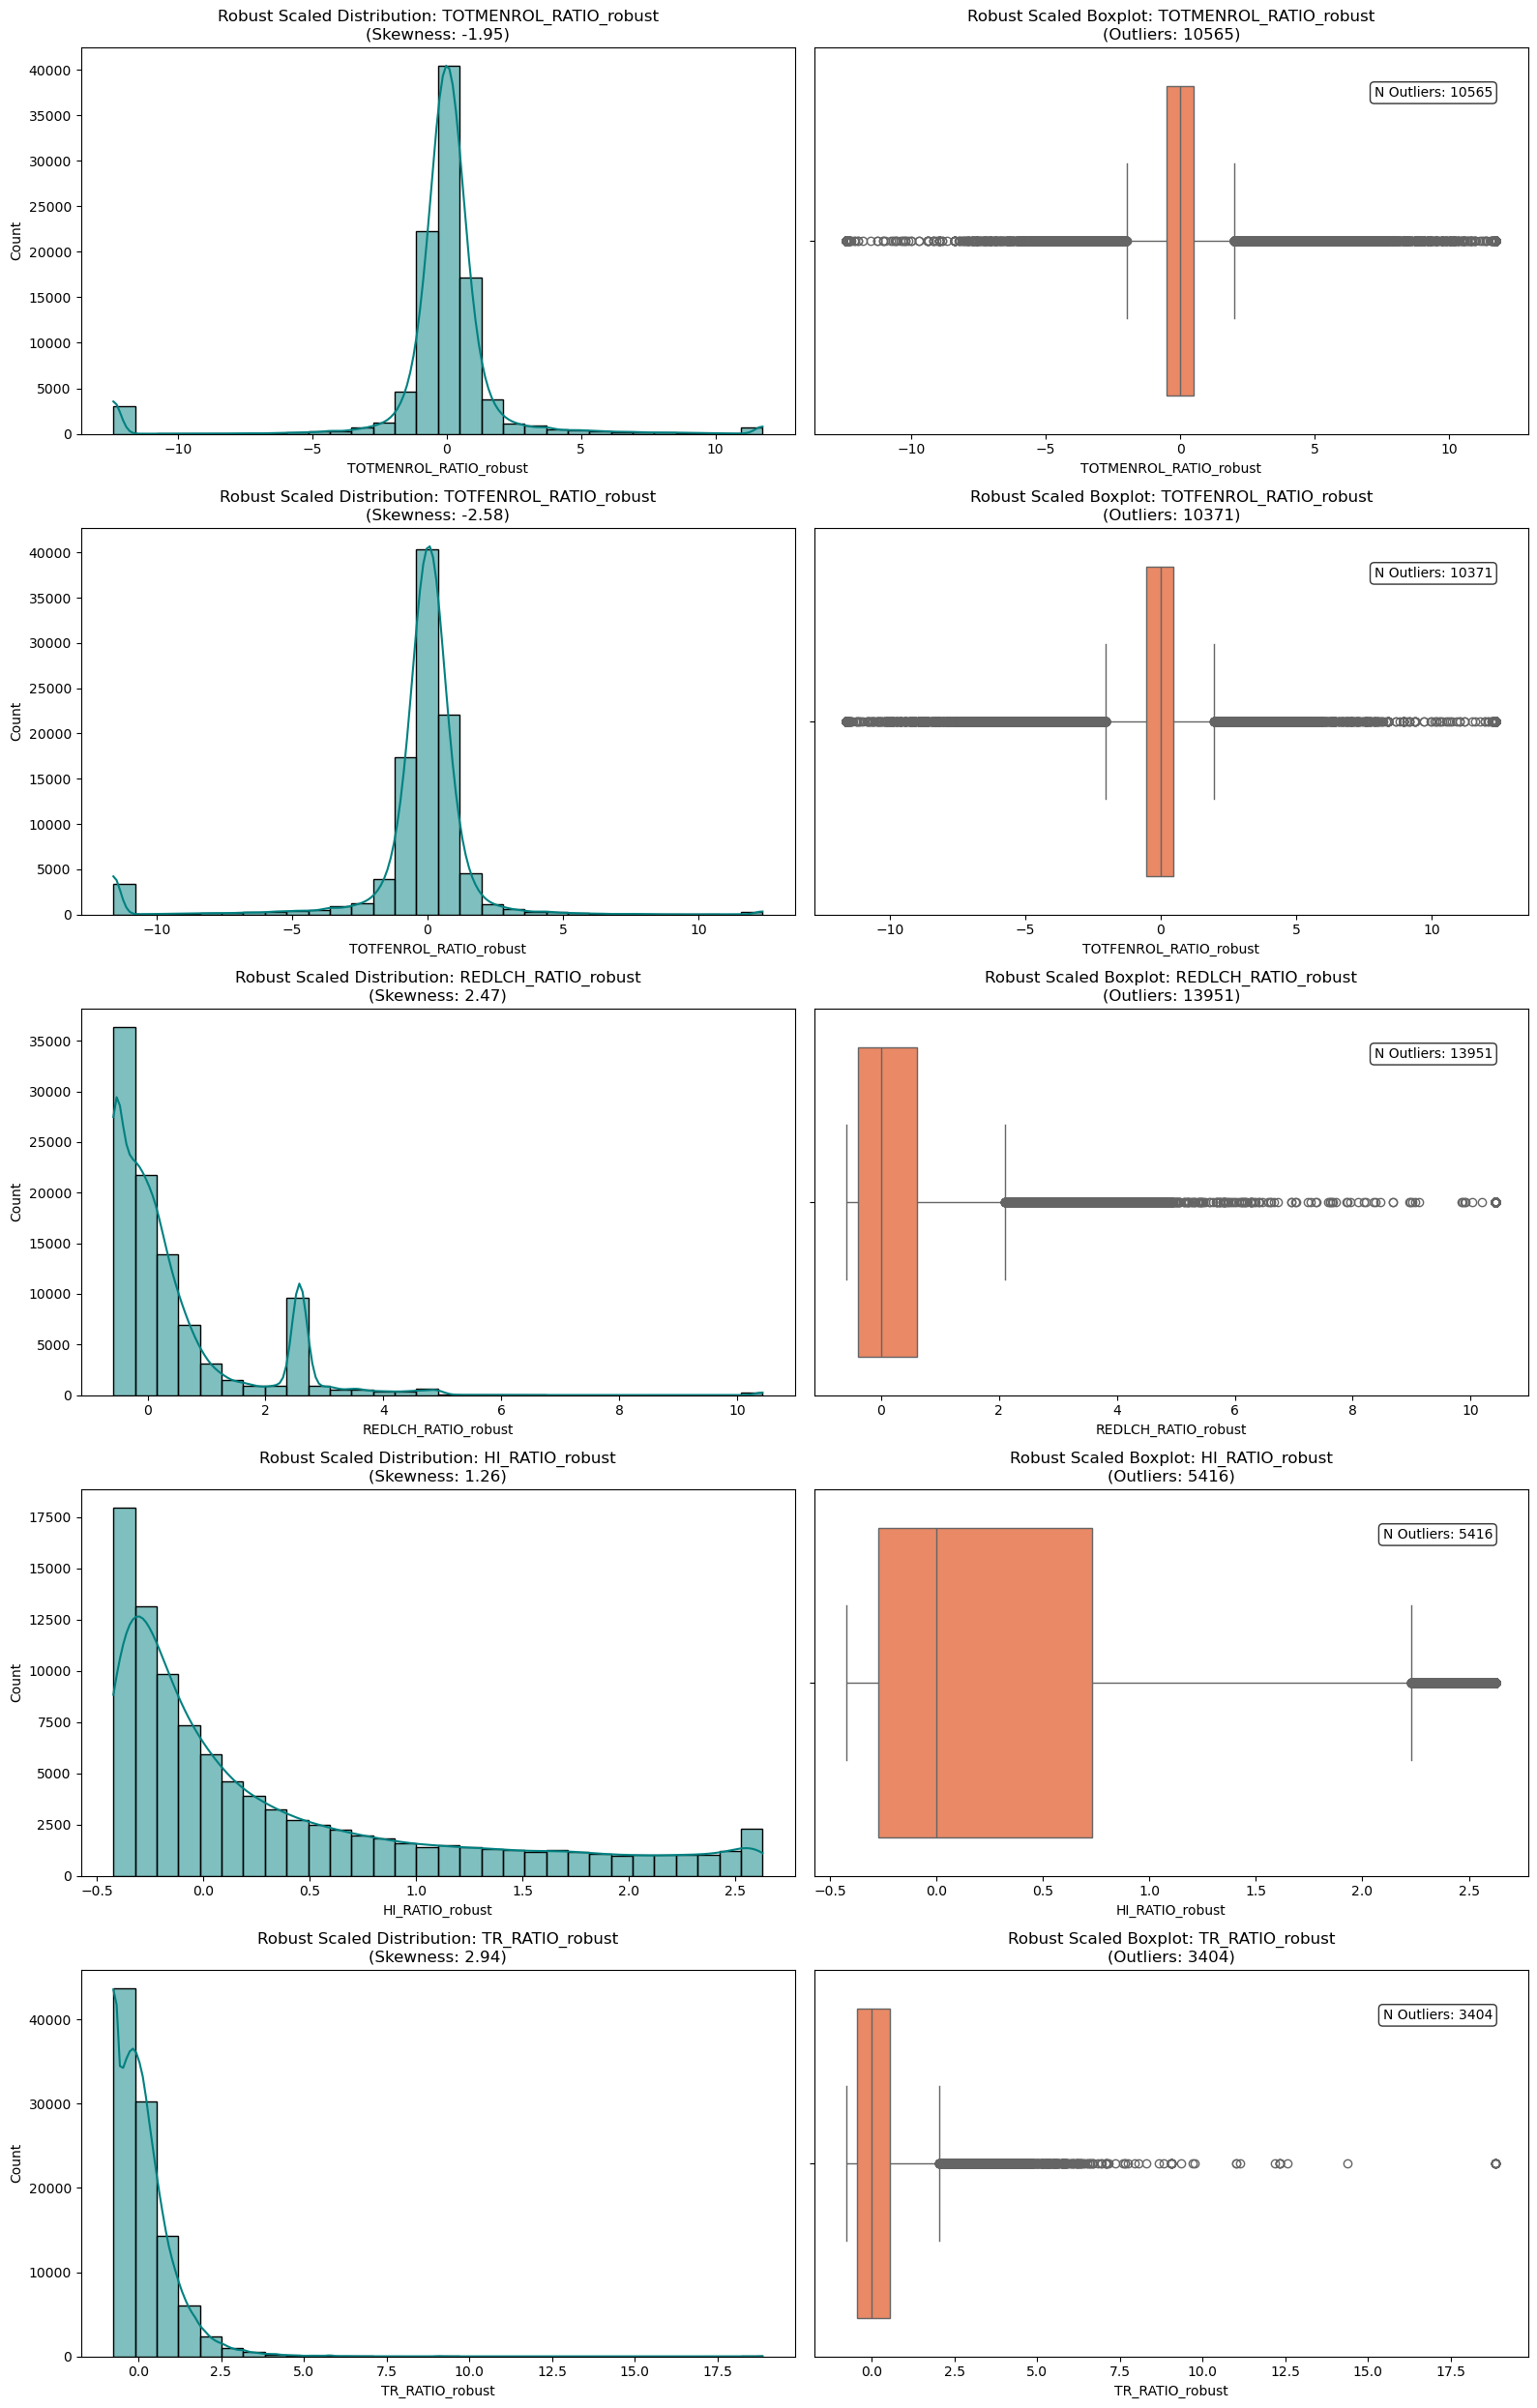

In [5]:
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns you want to scale
# You can use the original ratios or your log/bc transformed ones
robust_cols = ['TOTMENROL_RATIO', 'TOTFENROL_RATIO', 'REDLCH_RATIO', 'HI_RATIO', 'TR_RATIO']

scaler = RobustScaler()

# Apply the scaling
# We create new column names to keep track
for col in robust_cols:
    X[f'{col}_robust'] = scaler.fit_transform(X[[col]])

# Setup plotting for the new robust columns
fig, axes = plt.subplots(nrows=len(robust_cols), ncols=2, figsize=(16, 5 * len(robust_cols)))

for i, col in enumerate(robust_cols):
    robust_col = f'{col}_robust'
    data = X[robust_col]
    
    # Calculate Outliers using IQR for the scaled data
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ((data < lower_bound) | (data > upper_bound)).sum()
    
    skew_val = data.skew()

    # --- Plot 1: Histogram ---
    sns.histplot(data, kde=True, ax=axes[i, 0], color='teal', bins=30)
    axes[i, 0].set_title(f'Robust Scaled Distribution: {robust_col}\n(Skewness: {skew_val:.2f})')

    # --- Plot 2: Boxplot ---
    sns.boxplot(x=data, ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'Robust Scaled Boxplot: {robust_col}\n(Outliers: {outliers_count})')
    
    # Add annotation box
    axes[i, 1].text(0.95, 0.9, f'N Outliers: {outliers_count}', 
                    transform=axes[i, 1].transAxes, 
                    ha='right', va='top', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

##### Binning

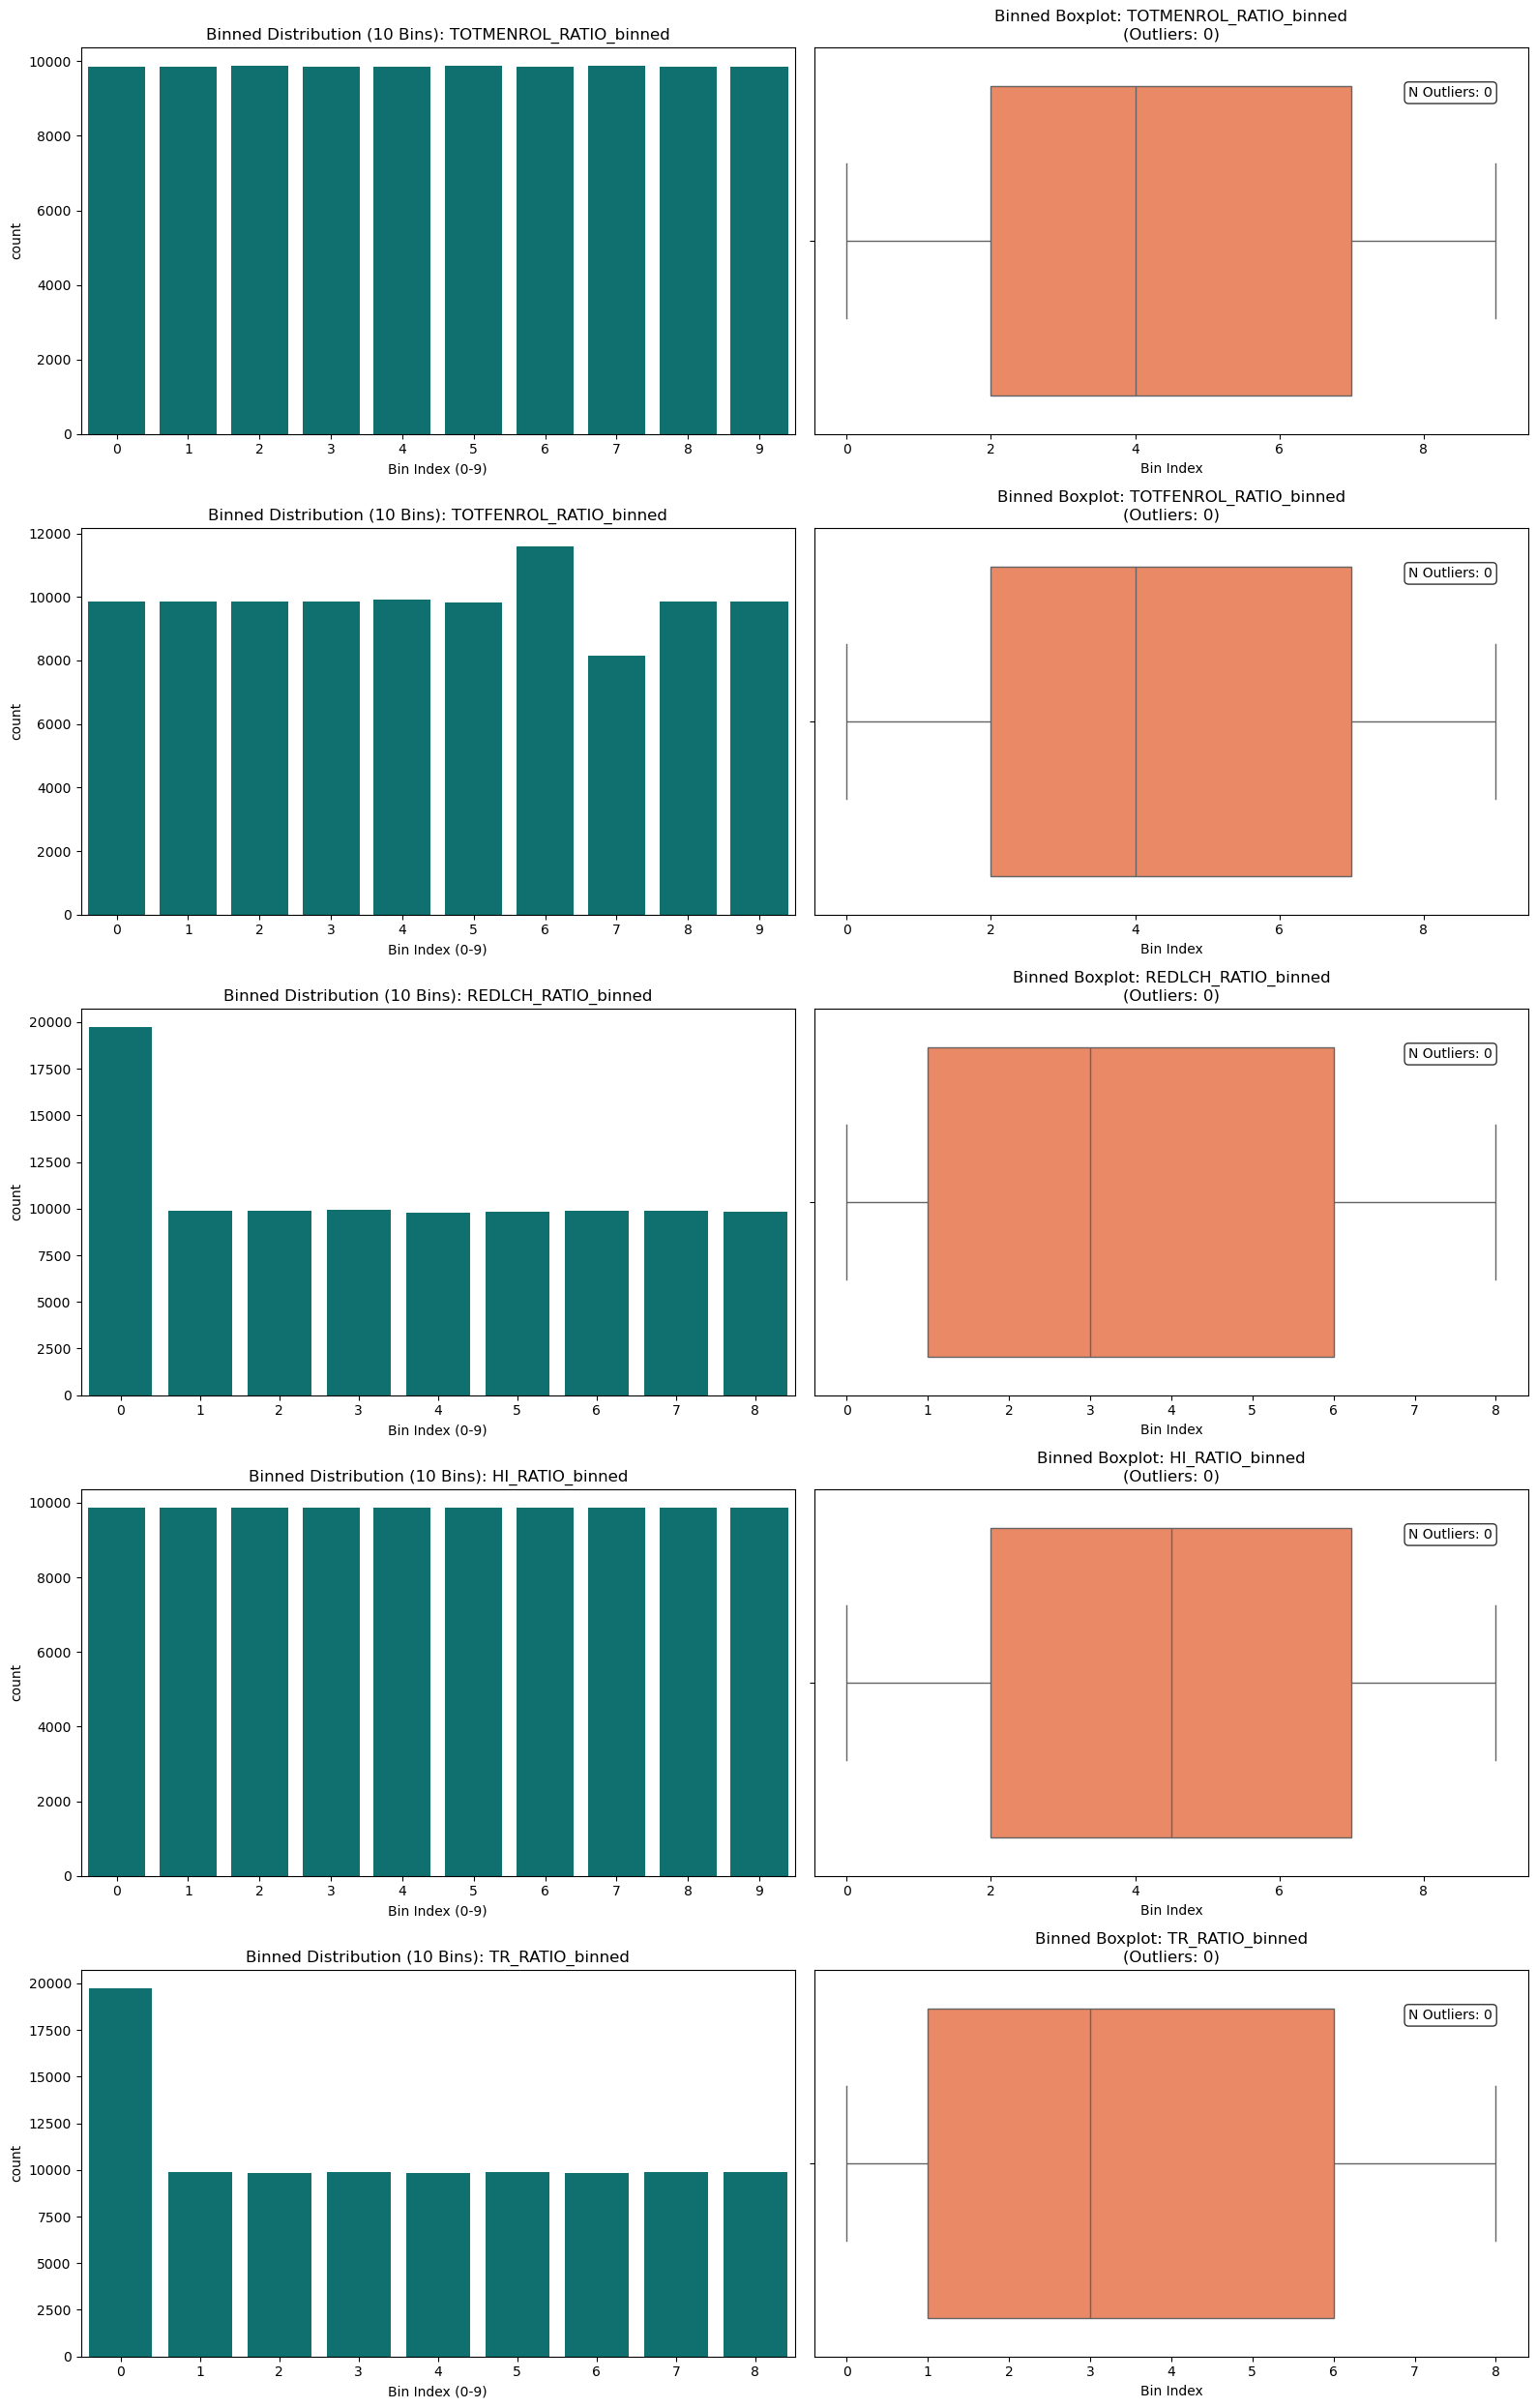

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns to bin
bin_cols = ['TOTMENROL_RATIO', 'TOTFENROL_RATIO', 'REDLCH_RATIO', 'HI_RATIO', 'TR_RATIO']

for col in bin_cols:
    # pd.qcut creates 10 equal-sized bins (deciles)
    # labels=False returns integer codes 0-9 instead of interval strings
    # duplicates='drop' handles cases where many values are identical (like 0.0)
    X[f'{col}_binned'] = pd.qcut(X[col], q=10, labels=False, duplicates='drop')

# Setup plotting for the new binned columns
fig, axes = plt.subplots(nrows=len(bin_cols), ncols=2, figsize=(16, 5 * len(bin_cols)))

for i, col in enumerate(bin_cols):
    binned_col = f'{col}_binned'
    data = X[binned_col]
    
    # Calculate Outliers using IQR (Expected to be 0 for binned data)
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ((data < lower_bound) | (data > upper_bound)).sum()
    
    # --- Plot 1: Countplot (Better than Histplot for discrete bins) ---
    sns.countplot(x=data, ax=axes[i, 0], color='teal')
    axes[i, 0].set_title(f'Binned Distribution (10 Bins): {binned_col}')
    axes[i, 0].set_xlabel('Bin Index (0-9)')

    # --- Plot 2: Boxplot ---
    sns.boxplot(x=data, ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'Binned Boxplot: {binned_col}\n(Outliers: {outliers_count})')
    axes[i, 1].set_xlabel('Bin Index')
    
    # Add annotation box
    axes[i, 1].text(0.95, 0.9, f'N Outliers: {outliers_count}', 
                    transform=axes[i, 1].transAxes, 
                    ha='right', va='top', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

#### Before vs After Performance

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import numpy as np
import pandas as pd

# Define column groups
count_cols = ['TOTMENROL', 'TOTFENROL', 'TOTFRL', 'REDLCH', 'HI', 'WH', 'TR']
ratio_cols = [f'{c}_RATIO' for c in count_cols]
log_target_cols = ['REDLCH_RATIO', 'HI_RATIO', 'TR_RATIO']
geo_cols = ['X', 'Y']

# 1. Baseline: Raw Counts
features_baseline = count_cols + geo_cols

# 2. Step 1: Normalization (Standard Scaling of raw counts)
X_norm = X.copy()
scaler_std = StandardScaler()
X_norm[count_cols] = scaler_std.fit_transform(X_norm[count_cols])
features_norm = count_cols + geo_cols

# 3. Step 2: Log Transformation (Applying log to the ratios)
X_log = X.copy()
for col in log_target_cols:
    X_log[f'{col}_log'] = np.log1p(X_log[col])
# For this set, we'll use the logged ratios + original ratios for the others
features_log = [f'{c}_log' if c in log_target_cols else c for c in ratio_cols] + geo_cols

# 4. Step 3: Robust Scaling (Applying Robust to all ratios)
X_robust = X.copy()
scaler_robust = RobustScaler()
X_robust[ratio_cols] = scaler_robust.fit_transform(X_robust[ratio_cols])
features_robust = ratio_cols + geo_cols

# 5. Step 4: Binning (Quantile binning into 10 categories)
X_bin = X.copy()
for col in ratio_cols:
    X_bin[f'{col}_bin'] = pd.qcut(X_bin[col], q=10, labels=False, duplicates='drop')
features_bin = [f'{c}_bin' for c in ratio_cols] + geo_cols

def evaluate_model(features_df, target, label):
    X_train, X_test, y_train, y_test = train_test_split(features_df, target, test_size=0.3, random_state=42)
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    
    return {
        'Step': label,
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    }

# Execute comparisons
results = []
results.append(evaluate_model(X[features_baseline], Y, "1. Baseline (Raw Counts)"))
results.append(evaluate_model(X_norm[features_norm], Y, "2. Normalized Raw Counts"))
results.append(evaluate_model(X_log[features_log], Y, "3. Log Transformed Ratios"))
results.append(evaluate_model(X_robust[features_robust], Y, "4. Robust Scaled Ratios"))
results.append(evaluate_model(X_bin[features_bin], Y, "5. Binned Ratios (10 Bins)"))

# Display performance table
performance_df = pd.DataFrame(results)
print("\n--- Performance Comparison Table ---")
print(performance_df.to_string(index=False))


--- Performance Comparison Table ---
                      Step      MAE     RMSE       R2
  1. Baseline (Raw Counts) 2.542676 4.511108 0.399596
  2. Normalized Raw Counts 2.542942 4.512058 0.399343
 3. Log Transformed Ratios 2.688643 4.586494 0.379362
   4. Robust Scaled Ratios 2.688716 4.586452 0.379373
5. Binned Ratios (10 Bins) 2.741765 4.658948 0.359598


#### Trade-Off

## Task 2. Hyperparameter Explanation

### Identify key hyperparameters

In [8]:
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

base_features = ['TOTMENROL', 'TOTFENROL', 'TOTFRL', 'REDLCH', 'HI', 'WH', 'TR', 'X', 'Y']
all_features = cat_cols + base_features 
# IMPORTANT: SVR requires scaling for all features to work correctly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[all_features])

# Split with the scaled data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.3, random_state=42)

# --- 1. Support Vector Regression (SVR) ---
# Tuning 'C': Regularization parameter (higher C means less regularization)
# Tuning 'epsilon': Specifies the "tube" within which no penalty is associated in the training loss
# Tuning 'kernel': 'rbf' is usually best for non-linear data; 'linear' is closer to Ridge
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1) 
svr_model.fit(X_train, y_train)
svr_preds = svr_model.predict(X_test)

# --- 2. Decision Tree Regressor ---
dt_model = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

# --- 3. Random Forest Regressor ---
rf_model = RandomForestRegressor(n_estimators=200, max_features='sqrt', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# --- Helper Function to Print Results ---
def print_metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}\n")

print_metrics("SVR (Kernel=RBF, C=1.0)", y_test, svr_preds)
print_metrics("Decision Tree (max_depth=5)", y_test, dt_preds)
print_metrics("Random Forest (n_estimators=200)", y_test, rf_preds)

--- SVR (Kernel=RBF, C=1.0) ---
MAE: 2.6199 | RMSE: 4.6491 | R2: 0.3623

--- Decision Tree (max_depth=5) ---
MAE: 2.9558 | RMSE: 4.8128 | R2: 0.3166

--- Random Forest (n_estimators=200) ---
MAE: 2.2863 | RMSE: 4.1286 | R2: 0.4971



## Task 3. Hyperparameter Tuning (Grid Search)
• At least 5–10 parameter combinations for Grid Search  
• Cross-validation = minimum 5-fold

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

# 1. Define Parameter Grids
# SVR Params: 
# 'C' is the penalty for error (higher = strict), 
# 'epsilon' is the width of the "no-penalty" tube.
svr_params = {
    'C': [0.1, 1, 10], 
    'epsilon': [0.01, 0.1],
    'kernel': ['rbf'] # RBF is generally the best starting point for non-linear data
}

dt_params = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 10, 20]
}

rf_params = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2'], # Removed None to speed up RF
    'max_depth': [10, 20]
}

# 2. Initialize Models (Replacing Ridge with SVR)
models = [
    ('SVR', SVR(), svr_params),
    ('Decision Tree', DecisionTreeRegressor(random_state=42), dt_params),
    ('Random Forest', RandomForestRegressor(random_state=42, n_jobs=-1), rf_params)
]

# 3. Run GridSearch
tuned_results = []

for name, model, params in models:
    print(f"Tuning {name}...")
    # Using neg_mean_absolute_error because GridSearchCV maximizes scores
    grid = GridSearchCV(estimator=model, param_grid=params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    
    # Ensure X_train is the SCALED version we created earlier!
    grid.fit(X_train, y_train) 
    
    # Get best model and predict
    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    tuned_results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })
# 4. Display Results
tuned_df = pd.DataFrame(tuned_results)
print("\n--- Final Tuned Results ---")
print(tuned_df[['Model', 'MAE', 'RMSE', 'R2']])

print("\nDetailed Best Parameters:")
for res in tuned_results:
    print(f"{res['Model']}: {res['Best Params']}")

Tuning SVR...
Tuning Decision Tree...
Tuning Random Forest...

--- Final Tuned Results ---
           Model       MAE      RMSE        R2
0            SVR  2.507959  4.517354  0.397932
1  Decision Tree  2.660977  4.650882  0.361813
2  Random Forest  2.311087  4.135567  0.495400

Detailed Best Parameters:
SVR: {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}
Decision Tree: {'max_depth': 10, 'min_samples_split': 20}
Random Forest: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200}


## Task 4. Model Evaluation & Best Model Selection